# RS-MAMBA

Literature:
- Main code: https://github.com/KyanChen/RSMamba
- RS-Mamba (but for segmentation): https://github.com/NJU-LHRS/Official_Remote_Sensing_Mamba
- MambaLRP: Explaining Selective State Space Sequence Models https://github.com/FarnoushRJ/MambaLRP

- https://huggingface.co/KyanChen/RSMamba
- MAIN ARTICLE: https://arxiv.org/pdf/2403.19654

- Advancing Long-Horizon Hydrological Forecasting: A Mamba-based Approach with Explainable AI for Generalized Streamflow Prediction: https://eartharxiv.org/repository/view/3617/
- https://arxiv.org/abs/2406.07592
- https://arxiv.org/abs/2404.02457
- https://arxiv.org/abs/2104.01375
- https://www.researchgate.net/publication/382135150_RS-Mamba_for_Large_Remote_Sensing_Image_Dense_Prediction
- https://aclanthology.org/2025.acl-long.76.pdf
- https://arxiv.org/abs/2312.00752


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, r2_score
from torch.utils.data import WeightedRandomSampler
import sys
from mmengine.config import Config



In [2]:
from mmpretrain.registry import MODELS

## Data preparation

In [3]:
CSV_PATH = "df_final.csv"
IMG_PATH = "images"

(128, 128, 3)
0.22


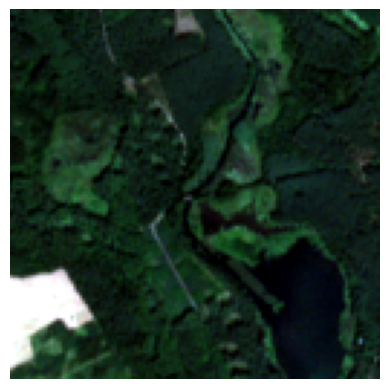

In [4]:
df = pd.read_csv(CSV_PATH)
row = df.iloc[1]

chunk_id = int(row["chunk_id"])
chunk = np.load(f"{IMG_PATH}/images_chunk_{chunk_id:03d}.npy")
image = chunk[int(row['id_in_chunk'])]

rgb_image = image[:, :, 1:4]

rgb_image = rgb_image.astype('float32')
rgb_image = rgb_image / rgb_image.max() if rgb_image.max() > 0 else rgb_image
print(rgb_image.shape)
print(row['flow'])

plt.imshow(rgb_image)
plt.axis('off')
plt.show()

In [5]:
df = pd.read_csv(CSV_PATH)
df.head()

,date,flow,chunk_id,id_in_chunk
0,2015-08-10,0.09,0,343
1,2015-08-10,0.22,3,318
2,2015-08-17,0.22,3,317
3,2015-11-25,1.12,1,364
4,2015-08-04,1.43,3,448


In [6]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df = df.sort_values('date').reset_index(drop=True)

train_df = df[df['year'] <= 2022].reset_index(drop=True)
val_df = df[df['year'] == 2023].reset_index(drop=True)
test_df = df[df['year'] == 2024].reset_index(drop=True)

print('Train:', len(train_df))
print('Val:', len(val_df))
print('Test:', len(test_df))

Train: 36993
Val: 7191
Test: 7328


### Transform data


In [9]:
def compute_statistics(df, images_num):

    sample = df.sample(min(images_num, len(df)), random_state=42)
    chunk_cache = {}
    rgb_pixel_values = []

    for _, row in sample.iterrows():
        chunk_id = int(row['chunk_id'])
        id_in_chunk = int(row['id_in_chunk'])
        if chunk_id not in chunk_cache:
            chunk_cache[chunk_id] = np.load(f'{IMG_PATH}/images_chunk_{chunk_id:03d}.npy',
            mmap_mode = 'r')

        image = chunk_cache[chunk_id][id_in_chunk]
        rgb_image = image[:, :, 1:4].astype('float32')

        p2  = np.percentile(rgb_image, 2)
        p98 = np.percentile(rgb_image, 98)
        rgb_image = np.clip(rgb_image, p2, p98)
        img = (rgb_image - p2) / (p98 - p2 + 1e-8)

        rgb_pixel_values.append(img.reshape(-1, 3))

    pixels = np.concatenate(rgb_pixel_values, axis=0)
    mean   = pixels.mean(axis=0).tolist()
    std    = pixels.std(axis=0).tolist()
    print(f'Mean = {mean}')
    print(f'std  = {std}')
    return mean, std

MEAN, STD = compute_statistics(train_df, 5000)

Mean = [0.20479999482631683, 0.20479999482631683, 0.20479999482631683]
std  = [0.24108798801898956, 0.25323355197906494, 0.23162099719047546]


In [10]:
rsmamba_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(
        mean=MEAN,
        std=STD
    )
])

In [11]:
def transform_images(image):
    rgb_image = image[:, :, 1:4]
    rgb_image = rgb_image.astype('float32')
     
    p2  = np.percentile(rgb_image, 2)
    p98 = np.percentile(rgb_image, 98)
    rgb_image = np.clip(rgb_image, p2, p98)
    rgb_image = (rgb_image - p2) / (p98 - p2 + 1e-8) 
    
    x = np.transpose(rgb_image, (2, 0, 1))
    x = torch.tensor(x, dtype=torch.float32)
    x = rsmamba_transform(x)
    return x

In [12]:
row = df.iloc[0]
chunk_id = int(row['chunk_id'])
id_in_chunk = int(row['id_in_chunk'])
    
chunk = np.load(f'{IMG_PATH}/images_chunk_{chunk_id:03d}.npy')
x = transform_images(chunk[0])
print(x.shape)

torch.Size([3, 224, 224])


/home/epaw0/miniconda3/envs/rsmamba/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


In [13]:
class RiverFlowDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self._chunk_cache = {}
    
    def __len__(self):
        return len(self.df)
    
    def load_chunk(self, chunk_id):
        if chunk_id not in self._chunk_cache:
            self._chunk_cache[chunk_id] = np.load(
                f'{IMG_PATH}/images_chunk_{chunk_id:03d}.npy',
                mmap_mode='r'
            )
        return self._chunk_cache[chunk_id]

    def __getitem__(self, idx):
        df_row = self.df.iloc[idx]
        chunk_id = int(df_row['chunk_id'])
        id_in_chunk = int(df_row['id_in_chunk'])

        chunk = self.load_chunk(chunk_id)
        image = chunk[id_in_chunk]

        x = transform_images(image)
        y = torch.tensor(np.log1p(df_row['flow']), dtype=torch.float32)
        return x, y
    

In [14]:
bins = [0, 50, 200, 500, 10000]
labels = pd.cut(train_df['flow'], bins=bins, labels=False, include_lowest=True)
print(labels.value_counts().sort_index())

class_counts = labels.value_counts()
weights = labels.map(lambda x: 1.0 / np.sqrt(class_counts[x]))
weights = torch.tensor(weights.values, dtype=torch.float)

sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


flow
0    33730
1     2046
2      610
3      607
Name: count, dtype: int64


In [15]:
train_loader = DataLoader(RiverFlowDataset(train_df), batch_size=32, sampler=sampler,  num_workers=0)
val_loader   = DataLoader(RiverFlowDataset(val_df),   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(RiverFlowDataset(test_df),  batch_size=32, shuffle=False, num_workers=0)

## Model RSMamba

In [16]:
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

True


In [17]:
RSMAMBA_ROOT = "/home/epaw0/RSMamba"
CONFIG_PATH = f"{RSMAMBA_ROOT}/configs/rsmamba/rsmamba_uc_b.py"
CHECKPOINT_PATH = "RSMamba-b_UC.pth"
#CHECKPOINT_PATH = "/mnt/data/student_ep/river_flow/checkpoints/RSMamba-b_AID.pth"

def model_preparation(use_checkpoint, checkpoint_path=None):

    sys.path.insert(0, RSMAMBA_ROOT)
    cfg = Config.fromfile(CONFIG_PATH)
    rsm = MODELS.build(cfg.model)

    if use_checkpoint:
        if checkpoint_path is None:
            raise ValueError(
                "checkpoint_path can't be None"
            )
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        if "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        else:
            state_dict = checkpoint

        state_dict.pop("head.fc.weight", None)
        state_dict.pop("head.fc.bias", None)
        missing, unexpected = rsm.load_state_dict(state_dict, strict=False)

    
    in_features = rsm.head.fc.in_features
    rsm.head.fc = nn.Linear(in_features, 1)

    if use_checkpoint:
        for param in rsm.backbone.parameters():
            param.requires_grad = False

        for param in rsm.head.parameters():
            param.requires_grad = True
        
        print("Checkpoint loaded.")
        print("Missing keys:", missing)
        print("Unexpected keys:", unexpected)

    return rsm 

rsm = model_preparation(True, checkpoint_path=CHECKPOINT_PATH)
for param in rsm.parameters():
    param.requires_grad = True

rsm = rsm.to(device)

print(rsm.head.fc)

09/14 23:39:05 - mmengine - INFO - Because batch augmentations are enabled, the data preprocessor automatically enables the `to_onehot` option to generate one-hot format labels.
Checkpoint loaded.
Missing keys: ['head.fc.weight', 'head.fc.bias']
Unexpected keys: []
Linear(in_features=192, out_features=1, bias=True)


### Trening

In [17]:
criterion = nn.MSELoss()
# optimizer = optim.AdamW(
#     filter(lambda p: p.requires_grad, rsm.parameters()),
#     lr=5e-4,
#     weight_decay=0.05
# )
optimizer = optim.AdamW(
    rsm.parameters(),
    lr=1e-5,
    weight_decay=0.1
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

num_epochs = 20
losses=[]
val_losses=[]
best_val_loss = float('inf')
patience = 7
epochs_without_improve = 0

In [16]:
OUTPUT_PATH= "/mnt/data/student_ep/river_flow/outputs"

In [ ]:
for epoch in range(num_epochs):
    rsm.train()
    train_loss = 0
    for batch_id, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        prediction = rsm(x, mode="tensor").squeeze(1)
        loss = criterion(prediction, y)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
        if batch_id % 100 == 0:
            print(f"batch {batch_id}/{len(train_loader)}, loss: {loss.item():.4f}")

    train_loss /= len(train_loader.dataset)
    losses.append(train_loss)

    rsm.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_prediction = rsm(x, mode="tensor").squeeze(1)
            loss = criterion(val_prediction, y)
            val_loss += loss.item() * x.size(0)
        
        val_loss /=len(val_loader.dataset)
        val_losses.append(val_loss)
    scheduler.step(val_loss)
    print(f'Epoch {epoch+1:02d}')
    print(f'Train_loss: {train_loss:.4f}')
    print(f'Val_loss: {val_loss:.4f}')

    if val_loss > best_val_loss:
        epochs_without_improve += 1
        print(f'No improvement - {epochs_without_improve}/{patience}')
        if epochs_without_improve >= patience:
            print('Early stopping.')
            break
    else:
        best_val_loss= val_loss
        epochs_without_improve = 0
        torch.save(rsm.state_dict(), f"{OUTPUT_PATH}/best_rsmamba_full.pth")

/home/student_ep/.conda/envs/rsmamba/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


batch 0/1157, loss: 15.1138
batch 100/1157, loss: 5.3601
batch 200/1157, loss: 3.9432
batch 300/1157, loss: 2.4514
batch 400/1157, loss: 2.7177
batch 500/1157, loss: 2.6069
batch 600/1157, loss: 1.8257
batch 700/1157, loss: 1.4780
batch 800/1157, loss: 1.0912
batch 900/1157, loss: 1.9442
batch 1000/1157, loss: 1.3445
batch 1100/1157, loss: 1.7563
Epoch 01
Train_loss: 2.3510
Val_loss: 1.2344
batch 0/1157, loss: 1.2206
batch 100/1157, loss: 1.0073
batch 200/1157, loss: 0.6396
batch 300/1157, loss: 1.2020
batch 400/1157, loss: 0.7832


In [17]:
epochs = range(1, len(losses) + 1)
plt.figure()
plt.plot(epochs, losses, label='Train loss')
plt.plot(epochs, val_losses, label='Validation loss')

plt.title('RSMamba - Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



NameError: name 'losses' is not defined

## Evaluation

In [18]:
rsm.load_state_dict(torch.load("best_rsmamba_whole.pth", map_location=device))

<All keys matched successfully>

In [19]:
total_params = sum(p.numel() for p in rsm.parameters())
trainable_params = sum(p.numel() for p in rsm.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print(f"Trainable [%]:        {100 * trainable_params / total_params:.2f}%")

Total parameters:     6,377,281
Trainable parameters: 6,377,281
Frozen parameters:    0
Trainable [%]:        100.00%


In [20]:
#Monte Carlo averaging
def predict_rsmamba_average(model, x, passes):
    model.eval()
    predictions = []

    with torch.no_grad():
        for _ in range(passes):
            pred = model(x, mode="tensor").squeeze(1)
            predictions.append(pred)

    predictions = torch.stack(predictions, dim=0)
    return predictions.mean(dim=0)


In [21]:
rsm.eval()

pred_y = []
true_y = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        prediction = predict_rsmamba_average(rsm, x, 5)

        pred_y.append(prediction.cpu().numpy())
        true_y.append(y.cpu().numpy())

all_preds = np.concatenate(pred_y)
all_trues = np.concatenate(true_y)

all_true_y = np.expm1(all_trues)
all_pred_y = np.expm1(all_preds)

mae = mean_absolute_error(all_true_y, all_pred_y)
rmse = np.sqrt(np.mean((all_true_y - all_pred_y) ** 2))
r2 = r2_score(all_true_y, all_pred_y)

flow_range = test_df["flow"].max() - test_df["flow"].min()

mae_percent = 100 * mae / flow_range
rmse_percent = 100 * rmse / flow_range

print("Test dataset")
print(f"MAE: {mae_percent:.2f}% ({mae:.4f})")
print(f"RMSE: {rmse_percent:.2f}% ({rmse:.4f})")
print(f"R2: {r2:.4f}")

/home/epaw0/miniconda3/envs/rsmamba/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Test dataset
MAE: 0.71% (15.6477)
RMSE: 3.25% (71.1082)
R2: 0.7304


In [22]:
def nse(y_true, y_pred):
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - numerator / denominator

In [23]:
nse_score = nse(all_true_y, all_pred_y)
print(f"NSE: {nse_score:.4f}")

NSE: 0.7304


In [24]:
me = np.mean(all_pred_y - all_true_y)

print("Mean Error:", me)

Mean Error: -7.030156


In [20]:
pred_y_val =[]
true_y_val =[]

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        prediction = predict_rsmamba_average(rsm, x, 5)
        
        pred_y_val.append(prediction.cpu().numpy())
        true_y_val.append(y.cpu().numpy())

all_preds_val =  np.concatenate(pred_y_val)
all_trues_val = np.concatenate(true_y_val)

all_true_y_val   = np.expm1(all_trues)
all_pred_y_val = np.expm1(all_preds)
   
mae_val = mean_absolute_error(all_true_y_val, all_pred_y_val)
rmse_val = np.sqrt(np.mean((all_true_y_val - all_pred_y_val) ** 2))
r2_val = r2_score(all_true_y_val, all_pred_y_val)

flow_range = val_df['flow'].max() - val_df['flow'].min()
mae_percent = 100 * mae_val / flow_range
rmse_percent = 100 * rmse_val / flow_range

print('Validation dataset')
print(f'MAE: {mae_percent:.2f}% ({mae_val:.4f})')
print(f'RMSE: {rmse_percent:.2f}% ({rmse_val:.4f})')
print(f'R2: {r2_val:.4f}')

/home/student_ep/.conda/envs/rsmamba/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Validation dataset
MAE: 0.84% (15.0231)
RMSE: 3.91% (69.9596)
R2: 0.7390


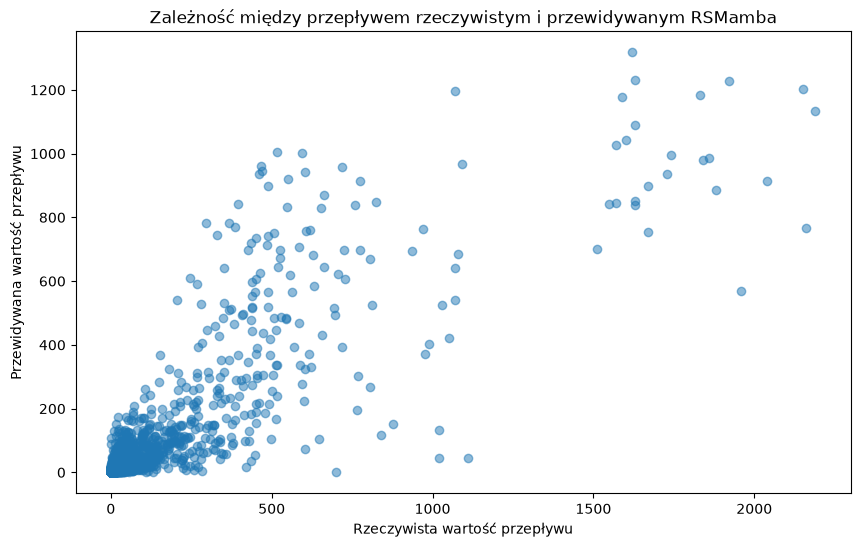

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(all_true_y, all_pred_y, alpha=0.5)
plt.title('Zależność między przepływem rzeczywistym i przewidywanym RSMamba')
plt.xlabel('Rzeczywista wartość przepływu')
plt.ylabel('Przewidywana wartość przepływu')
plt.show()

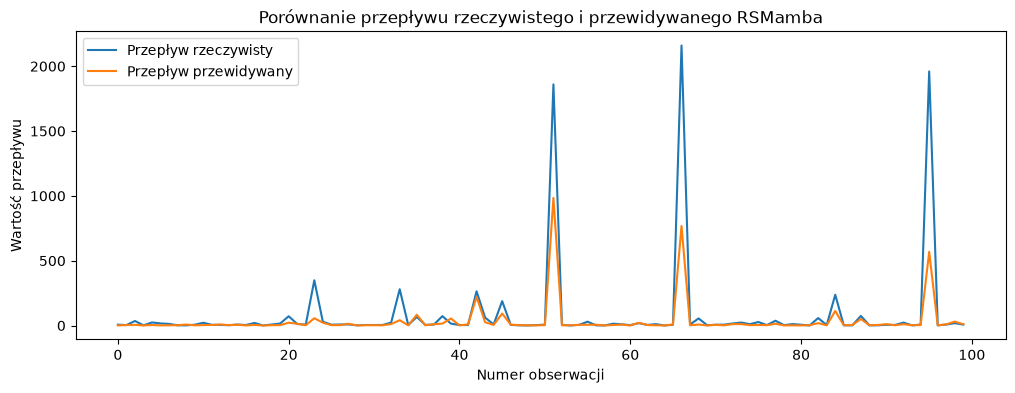

In [26]:
n = 100  
plt.figure(figsize=(12, 4))
plt.plot(all_true_y[:n], label='Przepływ rzeczywisty')
plt.plot(all_pred_y[:n], label='Przepływ przewidywany')
plt.xlabel('Numer obserwacji')
plt.ylabel('Wartość przepływu')
plt.title('Porównanie przepływu rzeczywistego i przewidywanego RSMamba')
plt.legend()
plt.show()


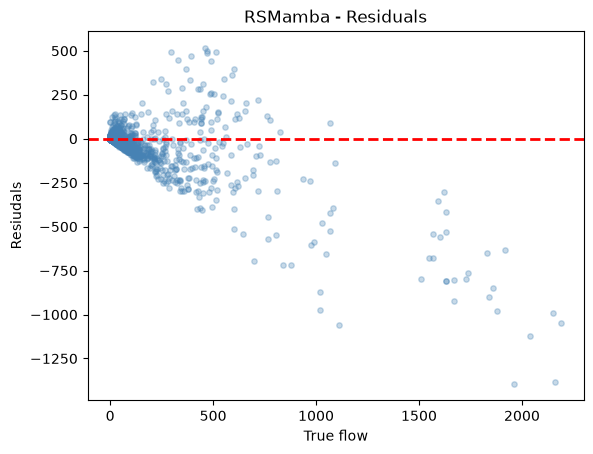

In [26]:
residuals = all_pred_y - all_true_y
plt.scatter(all_true_y, residuals, alpha=0.3, s=15, color='steelblue')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.title('RSMamba - Residuals')
plt.xlabel('True flow')
plt.ylabel('Resiudals')
plt.show()

## Features indetification

In [27]:
def occlusion_sensitivity(img_tensor, patch_size=32, stride=16):
    rsm.eval()

    baseline_prediction = predict_rsmamba_average(rsm, img_tensor, 5).item()
    _, _, H, W = img_tensor.shape

    heatmap = np.zeros((H, W), dtype=np.float32)
    hidden_counts = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):

            occluded_img = img_tensor.clone()
            occluded_img[:, :, y:y+patch_size, x:x+patch_size] = 0.0

            occluded_prediction = predict_rsmamba_average(rsm, occluded_img, 5).item()

            difference = abs(baseline_prediction - occluded_prediction)

            heatmap[y:y+patch_size, x:x+patch_size] += difference
            hidden_counts[y:y+patch_size, x:x+patch_size] += 1

    hidden_counts[hidden_counts == 0] = 1
    heatmap = heatmap / hidden_counts

    return heatmap, baseline_prediction

In [28]:

def plot_occlusion(indices, save_path, title):
    fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5 * len(indices)))

    for row_index, id in enumerate(indices):
        row = test_df.iloc[id]
        true_flow = row['flow']
        
        #Pobranie zdjęcia
        chunk_id = int(row['chunk_id'])
        id_in_chunk = int(row['id_in_chunk'])
        chunk = np.load(f'{IMG_PATH}/images_chunk_{chunk_id:03d}.npy', mmap_mode='r')
        image = chunk[id_in_chunk]

        x = transform_images(image)
        img_tensor = x.unsqueeze(0).to(device)

        # Heatmap
        heatmap, original_pred = occlusion_sensitivity(img_tensor, 32, 16)
        prediction_flow = np.expm1(original_pred)

        # Normalizacja
        img = x.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.float32(img)

        heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        # Wizualizacja
        axes[row_index, 0].imshow(img)
        axes[row_index, 0].set_title(f'Original image True: {true_flow:.2f}')
        axes[row_index, 0].axis('off')

        heatmap = axes[row_index, 1].imshow(heatmap_norm, cmap='jet')
        axes[row_index, 1].set_title(f'Heatmap  Pred: {prediction_flow:.2f}')
        axes[row_index, 1].axis('off')
        plt.colorbar(
            heatmap,
            ax=axes[row_index, 1],
            fraction=0.04,
            pad=0.04
        )

        axes[row_index, 2].imshow(img)
        axes[row_index, 2].imshow(heatmap_norm, cmap='jet', alpha=0.4)
        axes[row_index, 2].set_title('Occlusion Map Overlay')
        axes[row_index, 2].axis('off')

    plt.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [29]:
low_indices = [0,6253]
medium_indices = [1071,951] #833, 5886
high_indices = [95,2915] #,780

In [30]:
plot_occlusion(low_indices, f'{OUTPUT_PATH}/rs_occlusion_low.png', 'Occlusion Sensitivity - Low flow')
plot_occlusion(medium_indices, f'{OUTPUT_PATH}/rs_occlusion_medium.png', 'Occlusion Sensitivity - Medium flow')
plot_occlusion(high_indices,f'{OUTPUT_PATH}/rs_occlusion_high.png', 'Occlusion Sensitivity - High flow')

NameError: name 'OUTPUT_PATH' is not defined

## ŁĄCZONE

In [29]:
low_index = 2015
medium_index = 1071
high_index = 1082
very_high_index = 136

selected_indices = [
    low_index,
    medium_index,
    high_index,
    very_high_index
]

flow_labels = [
    "Niski przepływ (0-9 m³/s)",
    "Średni przepływ (10-99 m³/s)",
    "Wysoki przepływ (100-499 m³/s)",
    "Bardzo wysoki przepływ (≥500 m³/s)"
]

In [30]:
def plot_occlusion_combined(indices, flow_labels, save_path, title):

    fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5 * len(indices)))
    if len(indices) == 1:
            axes = np.expand_dims(axes, axis=0)

    for row_index, id in enumerate(indices):
        row = test_df.iloc[id]
        true_flow = row['flow']
        
        #Pobranie zdjęcia
        chunk_id = int(row['chunk_id'])
        id_in_chunk = int(row['id_in_chunk'])
        chunk = np.load(f'images/images_chunk_{chunk_id:03d}.npy', mmap_mode='r')
        image = chunk[id_in_chunk]

        x = transform_images(image)
        img_tensor = x.unsqueeze(0).to(device)
        
        # Heatmap
        heatmap, original_pred = occlusion_sensitivity(img_tensor, 32, 16)
        prediction_flow = np.expm1(original_pred)
        
        # Normalizacja
        img = x.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.float32(img)
        
        heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        
             
        # Wizualizacja
        axes[row_index, 0].imshow(img)
        axes[row_index, 0].set_title(f"{flow_labels[row_index]}\n"f"Rzeczywisty przepływ: {true_flow:.2f}")
        axes[row_index, 0].axis('off')
                 
        
        heatmap = axes[row_index, 1].imshow(heatmap_norm, cmap='jet')
        axes[row_index, 1].set_title(f"Mapa istotności\n" f"Predykcja: {prediction_flow:.2f}")        
        axes[row_index, 1].axis('off')
        plt.colorbar(
            heatmap,
            ax=axes[row_index, 1],
            fraction=0.04,
            pad=0.04
        )
        
        axes[row_index, 2].imshow(img)
        axes[row_index, 2].imshow(heatmap_norm, cmap='jet', alpha=0.4)
        axes[row_index, 2].set_title('Mapa istotności nałożona na obraz')
        axes[row_index, 2].axis('off')
        
    plt.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


In [32]:
results_rsmamba = test_df.copy()
results_rsmamba["pred_rsmamba"] = all_pred_y
results_rsmamba[["flow", "pred_rsmamba"]].to_csv("pred_rsmamba.csv", index=True)

In [33]:
results_rsmamba = test_df.copy()
results_rsmamba["pred_rsmamba"] = all_pred_y

results_rsmamba[
    ["chunk_id", "id_in_chunk", "flow", "pred_rsmamba"]
].to_csv("pred_rsmamba_2.csv", index=False)

/home/epaw0/miniconda3/envs/rsmamba/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


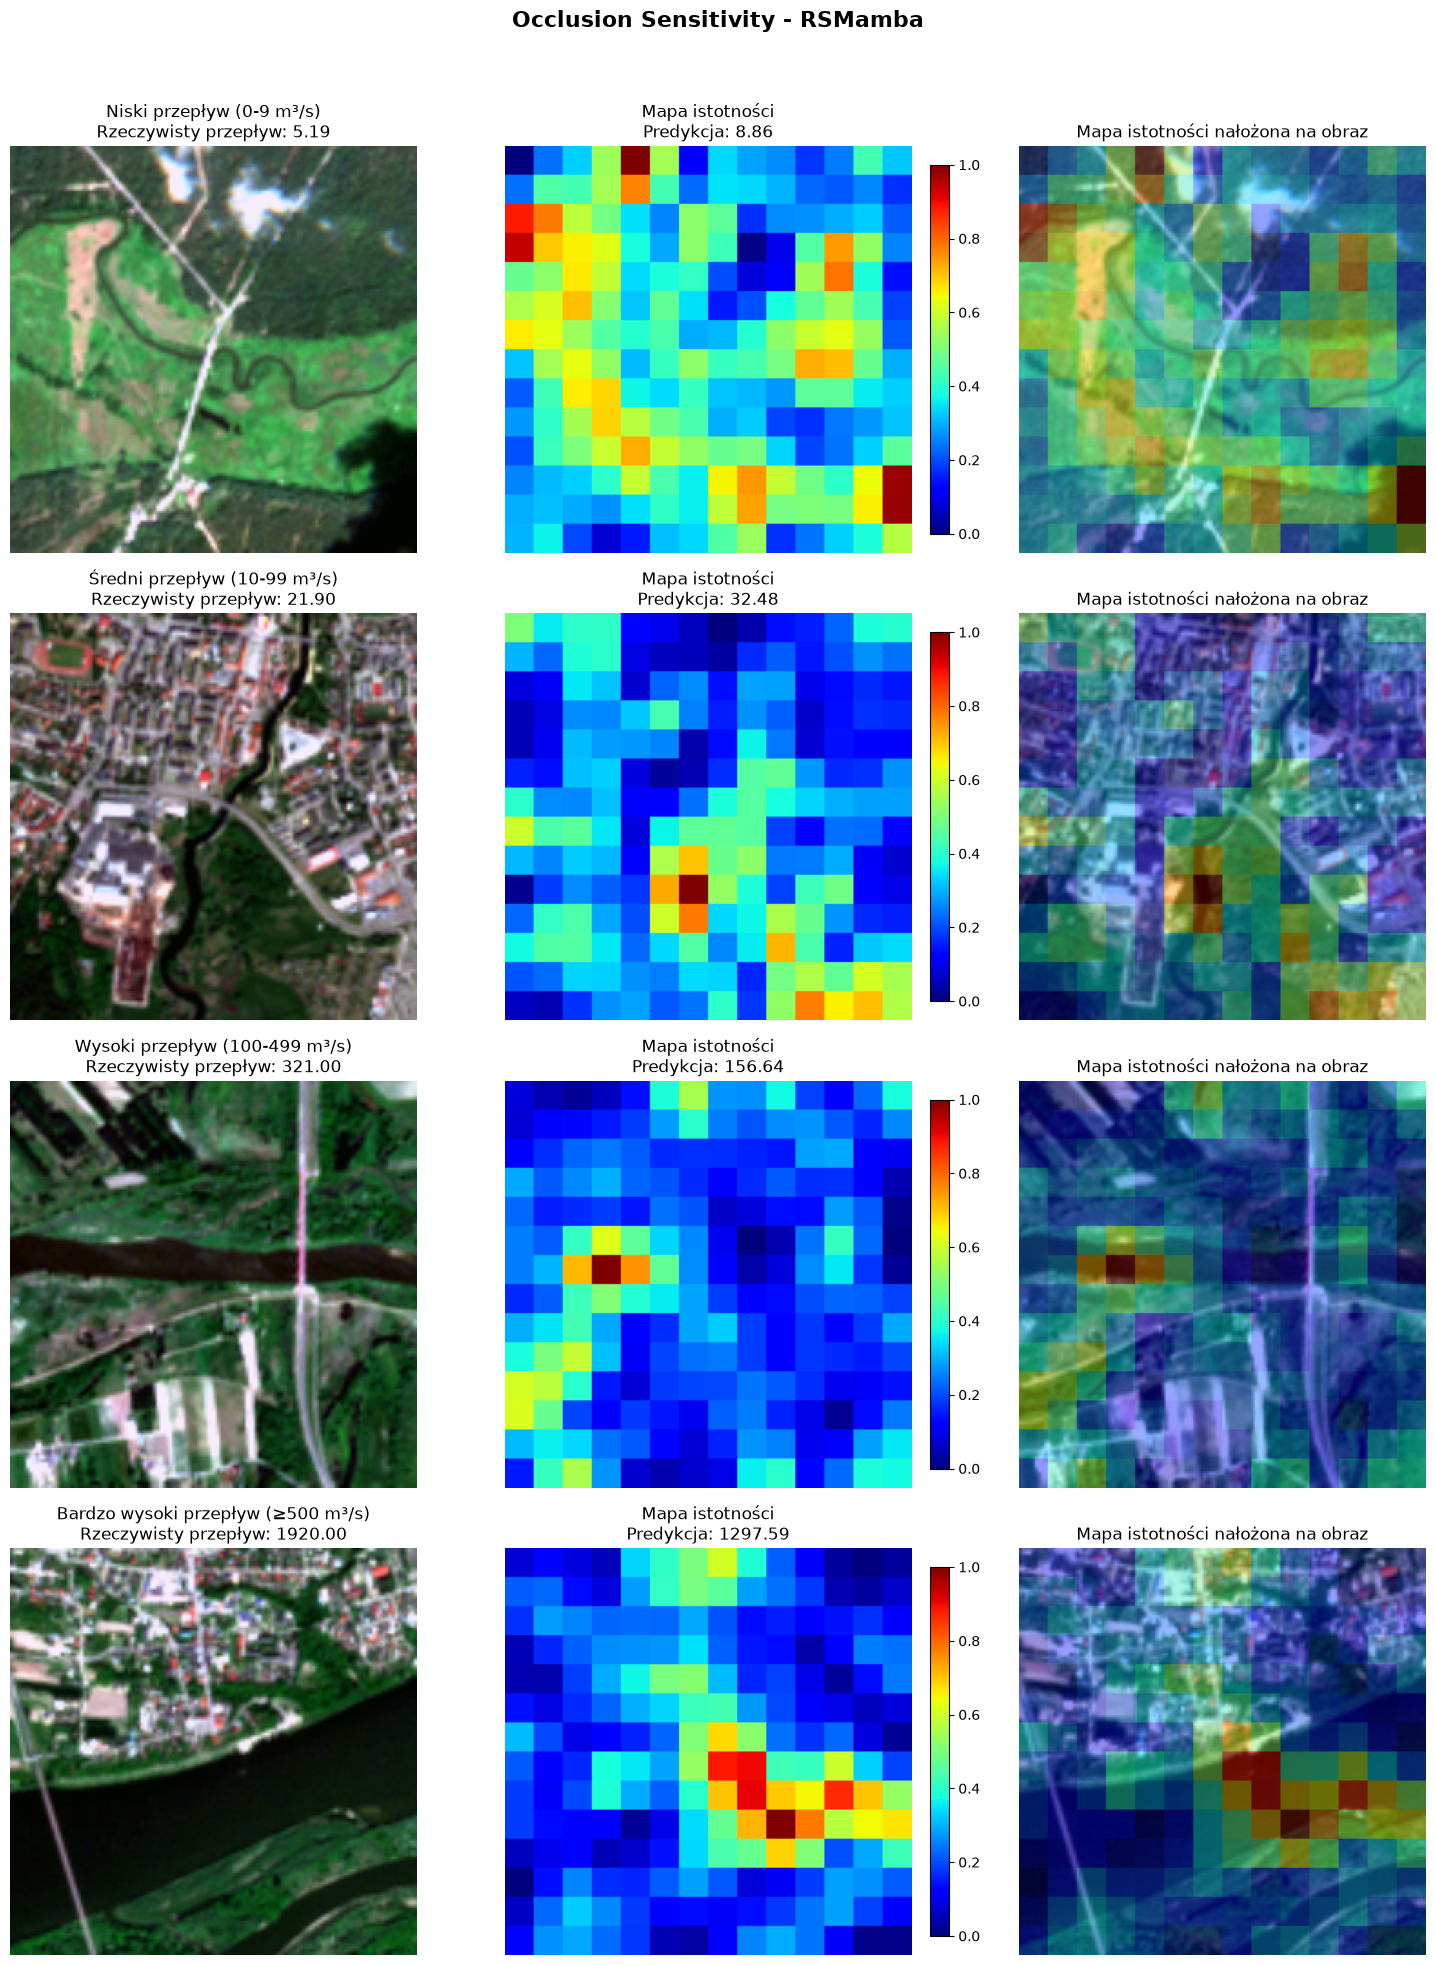

In [31]:
plot_occlusion_combined(
    selected_indices,
    flow_labels,
    title="Occlusion Sensitivity - RSMamba",
    save_path="rs_occlusion_all.png"
)